# <center> Практика. Статистические тесты в контексте EDA

## Постановка задачи

HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.

HR-агентство хочет выяснить, какие факторы влияют на зарплату специалиста Data Scientist, а так же ответить на следующие вопросы:

- Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
- Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
- Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
- Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

Определяем уровень значимости как: $\alpha=0.05$.

Ответить на эти вопросы нам помогут данные о зарплатах в сфере Data Science за 2020–2022 годы.

Данные содержат следующие столбцы:
*   *work_year* — год, в котором была выплачена зарплата;
*   *experience_level* — опыт работы на этой должности в течение года со следующими возможными значениями:
    - EN — Entry-level/Junior;
    - MI — Mid-level/Intermediate;
    - SE — Senior-level/Expert;
    - EX — Executive-level/Director;
*   *employment_type* — тип трудоустройства для этой роли:
    - PT — неполный рабочий день;
    - FT — полный рабочий день;
    - CT — контракт;
    - FL — фриланс;
*   *job_title* — роль, в которой соискатель работал в течение года;
*   *salary* — 	общая выплаченная валовая сумма заработной платы;
*   *salary_currency* — валюта выплачиваемой заработной платы в виде кода валюты ISO 4217;
*   *salary_in_usd* — зарплата в долларах США (валютный курс, делённый на среднее значение курса доллара США за соответствующий год через fxdata.foorilla.com);
*   *employee_residence* —	основная страна проживания сотрудника в течение рабочего года в виде кода страны ISO 3166;
*   *remote_ratio* — общий объём работы, выполняемой удалённо. Возможные значения:
    - 0 — удалённой работы нет (менее 20 %);
    - 50 — частично удалённая работа;
    - 100 — полностью удалённая работа (более 80 %);
*   *company_location* — страна главного офиса работодателя или филиала по контракту в виде кода страны ISO 3166;
*   *company_size* — среднее количество людей, работавших в компании в течение года:
    - S — менее 50 сотрудников (небольшая компания);
    - M — от 50 до 250 сотрудников (средняя компания);
    - L — более 250 сотрудников (крупная компания).

Оригинальный датасет: ["Data Science Job Salaries" (kaggle.com)](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)

## 1. Загрузка и обработка данных

### - Загрузка данных

In [164]:
# загружаем необходимые библиотеки
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms
import matplotlib.pyplot as plt
import seaborn as sns

# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.set_palette("Set2") 

In [165]:
# загружаем датасет 
data = pd.read_csv('data/ds_salaries.csv')
data.head(2)

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S


In [166]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


### - Провкерка на наличие пропусков и дубликатов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


<Axes: >

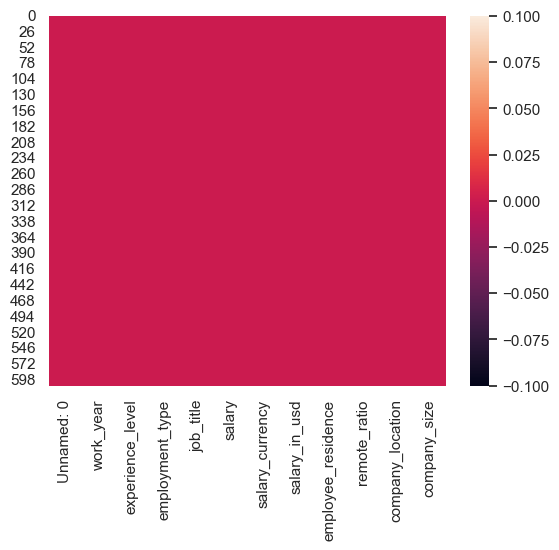

In [167]:
# получаем основную информацию о датасете
data.info()
# убеждаемся, что датасет без пропусков
sns.heatmap(data.isnull()) 

In [168]:
# Проверим данные на наличие полных дубликатов
print('Количество дубликатов: {}'.format(data[data.duplicated()].shape[0]))

Количество дубликатов: 0


В датасете 607 записей, пропущенных значений и дупликатов нет.В датасете нет дупликатов. Типы столбцов соответствуют их содержанию.

### - Определение признаков для использования в исследовании

Проведём корреляционный анализ датасета и используем для этого тепловую карту корреляций признаков

<Axes: >

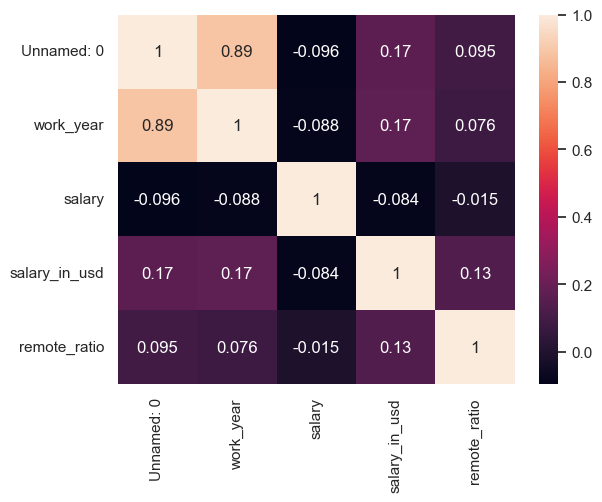

In [169]:
# отсеиваем числовые признаки и включаем отображение коэффициентов
sns.heatmap(data.corr(numeric_only=True), annot=True)

По тепловой карте видно что признак Unnamed сильно корелирует с work_year, вероятно это связано с тем что таблица отсортирована по признаку work_year, а Unnamed содержит в себе порядковую нумерацию.

- Удалим признак Unnamed не имеющий значения для статистического анализа;
- Удалим признак salary, аналогичный более универсальному и поддающемуся статестической оработке признаку salary_in_usd;
- Удалим признак salary_currency, поскольку мы будем оперировать зарплатой уже переведенной в доллары США. Так же будет удален признак Unnamed не имеющий значения для статистического анализа.


In [170]:
# удаляем признаки
df = data.drop(columns=['Unnamed: 0', 'salary', 'salary_currency'])
# выводим получившийся датасет и информацию о нем
display(df.head(2))
df.info()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary_in_usd       607 non-null    int64 
 5   employee_residence  607 non-null    object
 6   remote_ratio        607 non-null    int64 
 7   company_location    607 non-null    object
 8   company_size        607 non-null    object
dtypes: int64(3), object(6)
memory usage: 42.8+ KB


### - Классификация признаков на числовые и категориальные

Категориальные признаки:
*   *work_year* — год, в котором была выплачена зарплата;
*   *experience_level* — опыт работы на этой должности в течение года;
*   *employment_type* — тип трудоустройства для этой роли;
*   *job_title* — роль, в которой соискатель работал в течение года;
*   *employee_residence* —	основная страна проживания сотрудника в течение рабочего года в виде кода страны ISO 3166;
*   *remote_ratio* — общий объём работы, выполняемой удалённо;
*   *company_location* — страна главного офиса работодателя или филиала по контракту в виде кода страны ISO 3166;
*   *company_size* — среднее количество людей, работавших в компании в течение года;
    
Числовые признаки:
*   *salary_in_usd* — зарплата в долларах США (валютный курс, делённый на среднее значение курса доллара США за соответствующий год через fxdata.foorilla.com);

### - Определение основных статистических характеристик для каждого из признаков

Для определения основных статестических характеристик прзнаков датасета построим отчет с использованием библиотеки sweetviz

In [171]:
import sweetviz as sv
report = sv.analyze(df)
report.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Отчет по основным статистическим характеристикам признакам датасета получен.

## 2. Разведывательный анализ данных

### 2.1. Визуальный анализ данных

### - Распределение оплаты труда по профессии Data Scientist за 2020-2022 годы

In [172]:
# фильтруем професии в датафрейме
filtred_ds = df[(df.job_title == 'Data Scientist')]

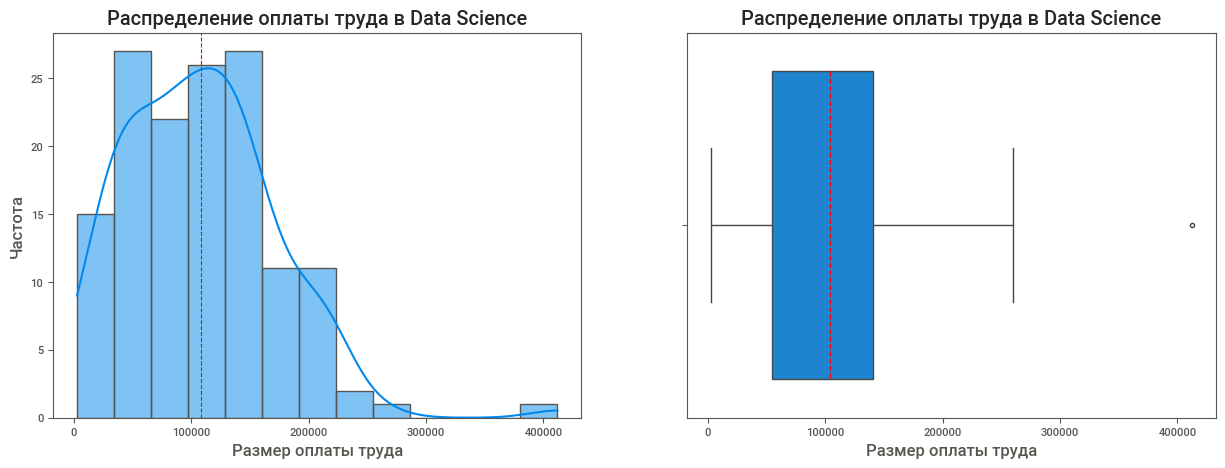

In [173]:
# строим графики распределения зарплат
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(filtred_ds['salary_in_usd'], kde=True, ax=axes[0])
axes[0].set(xlabel='Размер оплаты труда', ylabel='Частота')
axes[0].set_title('Распределение оплаты труда в Data Science')
axes[0].axvline(filtred_ds['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(filtred_ds['salary_in_usd'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Размер оплаты труда')
axes[1].set_title('Распределение оплаты труда в Data Science')

plt.show()

In [174]:
# вычисляем основные статистические показатели
data_agg = filtred_ds['salary_in_usd'].describe().round(2).to_frame()
data_agg.columns = ['Размер оплаты труда']
data_agg

,Размер оплаты труда
count,143.00
mean,108187.83
std,64112.84
min,2859.00
25%,54724.00
50%,103691.00
75%,140850.00
max,412000.00


Распределение оплаты труда отлично от нормального, имеются выбросы.

### - Оплата труда в зависимости от года, в котором была выплачена зарплата

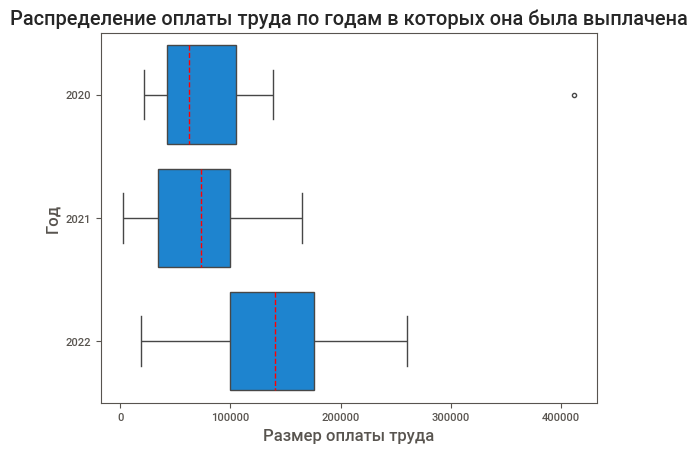

In [175]:
# строим график
ax = sns.boxplot(filtred_ds, x='salary_in_usd', y='work_year', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер оплаты труда', ylabel='Год')
plt.title('Распределение оплаты труда по годам в которых она была выплачена')
plt.show()

In [176]:
# вычисляем основные статистические показатели
data_agg = filtred_ds.groupby('work_year')['salary_in_usd'].describe().round(2)
print('Распределение оплаты труда по годам в которых она была выплачена')
data_agg

Распределение оплаты труда по годам в которых она была выплачена


,count,mean,std,min,25%,50%,75%,max
work_year,,,,,,,,
2020,21.0,85970.52,81436.65,21669.0,42197.0,62726.0,105000.0,412000.0
2021,45.0,70671.73,45422.97,2859.0,33808.0,73000.0,100000.0,165000.0
2022,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


Распределение оплаты труда по годам имеет тенденцию к увеличению средних и медианных значений за период с 2020 по 2022 гг., в тоже время отмечается уменьшение количества выбросов и уменьшение максимальных значений, что может свидетельствовать как о росте спроса на данные виды специальностей в ИТ, так и о стандартизации квалификационных требований и компетенций самих соискателей, что выражено в уменьшении разницы между минимальными и максимальными величинами оплаты труда.

Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистические тесты.

### - Оплата труда в зависимости от опыта работы соискателя

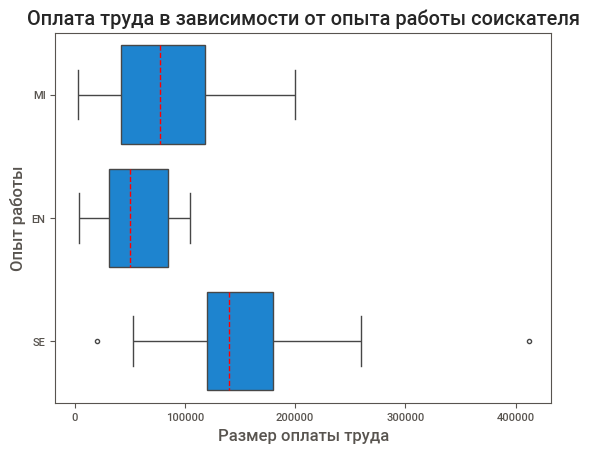

In [177]:
# строим график
ax = sns.boxplot(filtred_ds, x='salary_in_usd', y='experience_level', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер оплаты труда', ylabel='Опыт работы')
plt.title('Оплата труда в зависимости от опыта работы соискателя')
plt.show()

In [178]:
# вычисляем основные статистические показатели
data_agg = filtred_ds.groupby('experience_level')['salary_in_usd'].describe().round(2)
print('Оплата труда в зависимости от опыта работы соискателя')
data_agg

Оплата труда в зависимости от опыта работы соискателя


,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,22.0,55330.91,31237.82,4000.0,31474.0,50483.5,85027.25,105000.0
MI,60.0,82039.13,46869.58,2859.0,41768.0,77479.0,118264.75,200000.0
SE,61.0,152971.02,58985.40,20171.0,120000.0,140400.0,180000.00,412000.0


Среднее значение оплаты труда увеличивается с опытом работы соискателя. 

Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистические тесты.

### - Зависимость оплаты труда от типа трудоустройства

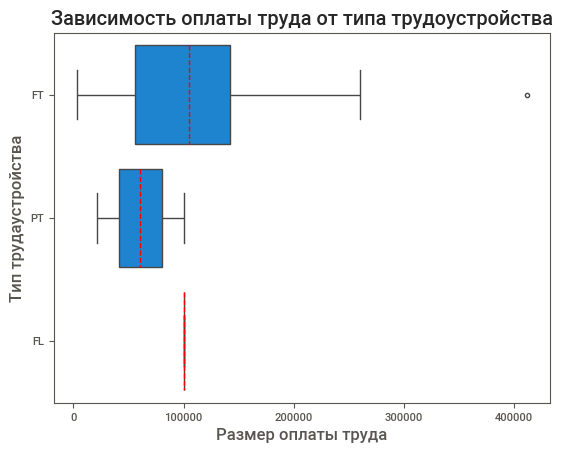

In [179]:
# строим график
ax = sns.boxplot(filtred_ds, x='salary_in_usd', y='employment_type', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер оплаты труда', ylabel='Тип трудаустройства')
plt.title('Зависимость оплаты труда от типа трудоустройства')
plt.show()

In [180]:
# вычисляем основные статистические показатели
data_agg = filtred_ds.groupby('employment_type')['salary_in_usd'].describe().round(2)
print('Зависимость оплаты труда от типа трудоустройства')
data_agg

Зависимость оплаты труда от типа трудоустройства


,count,mean,std,min,25%,50%,75%,max
employment_type,,,,,,,,
FL,1.0,100000.00,NaN,100000.0,100000.00,100000.0,100000.00,100000.0
FT,140.0,108922.79,64372.43,2859.0,55490.00,104796.0,141975.00,412000.0
PT,2.0,60834.50,55388.38,21669.0,41251.75,60834.5,80417.25,100000.0


Распределения оплаты труда различно для разных типов трудоустройства, однако на графике четко видно что средняя зарплата сотрудников на полном рабочем дне выше. 

Чтобы определить, являются ли эти различия статистически значимыми, необходимы статистические тесты.

### - Зависимость оплаты труда от роли в которой соискатель работал в течение года

In [181]:
# фильтруем професси в датафрейме
filtred_ds_de = df[(df.job_title == 'Data Scientist') | (df.job_title == 'Data Engineer')]

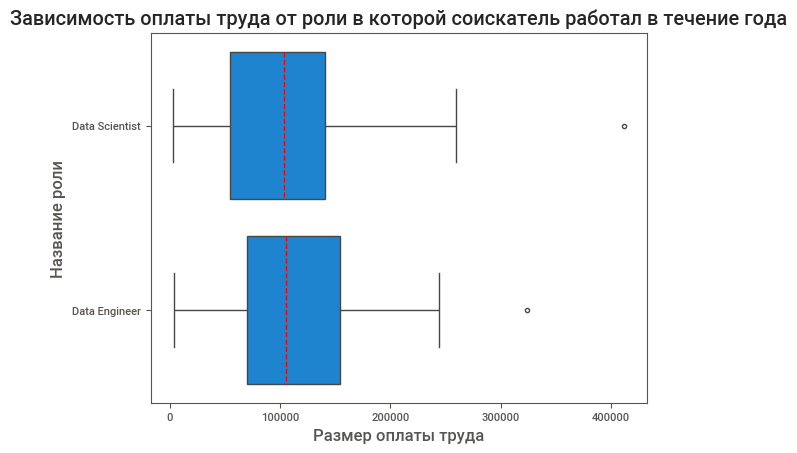

In [182]:
# строим график
ax = sns.boxplot(filtred_ds_de, x='salary_in_usd', y='job_title', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер оплаты труда', ylabel='Название роли')
plt.title('Зависимость оплаты труда от роли в которой соискатель работал в течение года')
plt.show()

In [183]:
# вычисляем основные статистические показатели
data_agg = filtred_ds_de.groupby('job_title')['salary_in_usd'].describe().round(2)
print('Зависимость оплаты труда от роли в которой соискатель работал в течение года')
data_agg

Зависимость оплаты труда от роли в которой соискатель работал в течение года


,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
Data Engineer,132.0,112725.00,57629.08,4000.0,70039.5,105500.0,154600.0,324000.0
Data Scientist,143.0,108187.83,64112.84,2859.0,54724.0,103691.0,140850.0,412000.0


Распределения по названию роли соискателя незначительно отлчаются. 

Чтобы определить, являются ли эти различия статистически значимыми, необходимы статистические тесты.

### - Зависимость оплаты труда от страны проживания в течении рабочего года

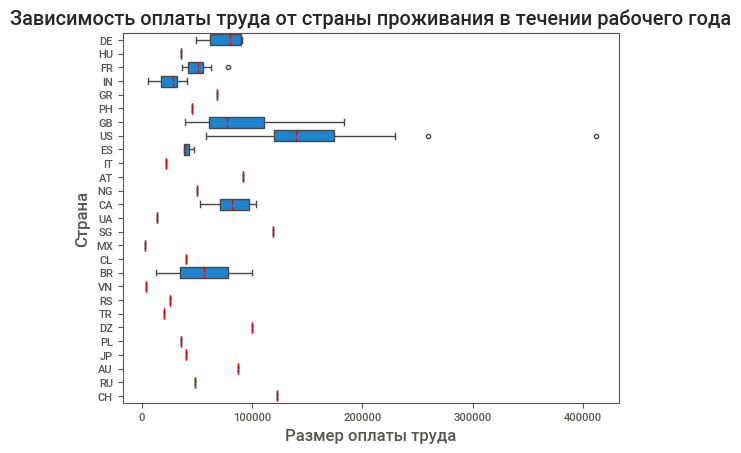

In [184]:
# строим график
ax = sns.boxplot(filtred_ds, x='salary_in_usd', y='employee_residence', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер оплаты труда', ylabel='Страна')
plt.title('Зависимость оплаты труда от страны проживания в течении рабочего года')
plt.show()

In [185]:
# вычисляем основные статистические показатели
data_agg = filtred_ds.groupby('employee_residence')['salary_in_usd'].describe().round(2)
print('Зависимость оплаты труда от страны проживания в течении рабочего года')
data_agg

Зависимость оплаты труда от страны проживания в течении рабочего года


,count,mean,std,min,25%,50%,75%,max
employee_residence,,,,,,,,
AT,1.0,91237.00,NaN,91237.0,91237.00,91237.0,91237.00,91237.0
AU,1.0,86703.00,NaN,86703.0,86703.00,86703.0,86703.00,86703.0
BR,2.0,56450.50,61588.29,12901.0,34675.75,56450.5,78225.25,100000.0
CA,6.0,81489.17,19500.74,52396.0,70945.50,81756.0,96934.50,103691.0
CH,1.0,122346.00,NaN,122346.0,122346.00,122346.0,122346.00,122346.0
CL,1.0,40038.00,NaN,40038.0,40038.00,40038.0,40038.00,40038.0
DE,7.0,74773.71,16834.87,49268.0,62096.50,79833.0,89694.00,90734.0
DZ,1.0,100000.00,NaN,100000.0,100000.00,100000.0,100000.00,100000.0
ES,3.0,41136.67,4935.34,37825.0,38300.50,38776.0,42792.50,46809.0


Среднее значение оплаты труда значительно отличается по разным странам проживания соискателей. Соискатели проживающие в US имеют наибольшую средню оплату труда.

Чтобы определить, являются ли эти различия статистически значимыми, необходимы статистические тесты.

### - Зависимость оплаты труда от доли работы, выполняемой удаленно

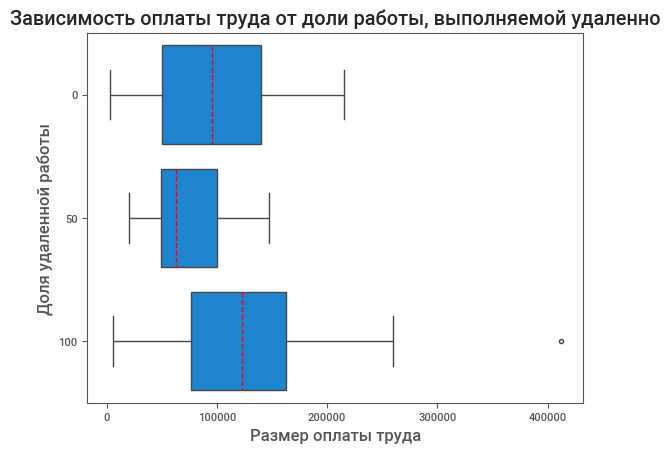

In [186]:
# строим график
ax = sns.boxplot(filtred_ds, x='salary_in_usd', y='remote_ratio', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер оплаты труда', ylabel='Доля удаленной работы')
plt.title('Зависимость оплаты труда от доли работы, выполняемой удаленно')
plt.show()

In [187]:
# вычисляем основные статистические показатели
data_agg = filtred_ds.groupby('remote_ratio')['salary_in_usd'].describe().round(2)
print('Зависимость оплаты труда от доли работы, выполняемой удаленно')
data_agg

Зависимость оплаты труда от доли работы, выполняемой удаленно


,count,mean,std,min,25%,50%,75%,max
remote_ratio,,,,,,,,
0,39.0,99520.74,58259.42,2859.0,50294.5,95550.0,140400.0,215300.0
50,25.0,74504.08,35602.82,20171.0,49646.0,62726.0,100000.0,147000.0
100,79.0,123125.94,69370.99,5679.0,76366.0,123000.0,162500.0,412000.0


Среднее значение оплаты труда значительно отличается в зависимости от доли работы, выполняемой удаленно. 

Чтобы определить, являются ли эти различия статистически значимыми, необходимы статистические тесты.

### - Зависимость заработной платы от страны где размещен главный офис компании

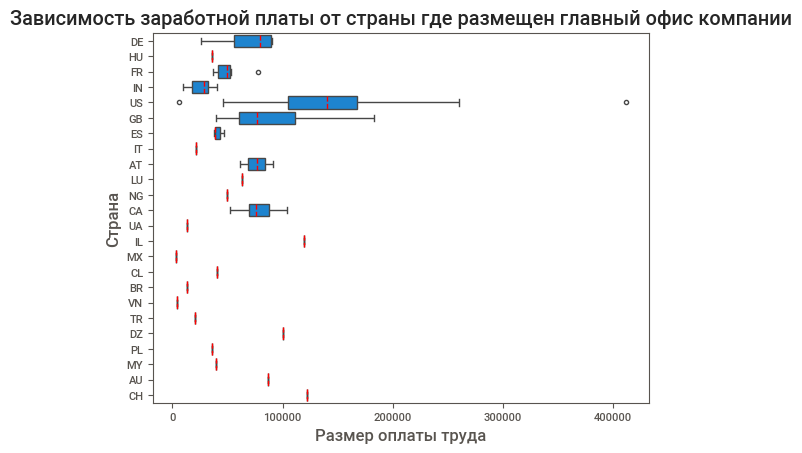

In [188]:
# строим график
ax = sns.boxplot(filtred_ds, x='salary_in_usd', y='company_location', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер оплаты труда', ylabel='Страна')
plt.title('Зависимость заработной платы от страны где размещен главный офис компании')
plt.show()

In [189]:
# вычисляем основные статистические показатели
data_agg = filtred_ds.groupby('company_location')['salary_in_usd'].describe().round(2)
print('Зависимость заработной платы от страны где размещен главный офис компании')
data_agg

Зависимость заработной платы от страны где размещен главный офис компании


,count,mean,std,min,25%,50%,75%,max
company_location,,,,,,,,
AT,2.0,76352.00,21050.57,61467.0,68909.5,76352.0,83794.50,91237.0
AU,1.0,86703.00,NaN,86703.0,86703.0,86703.0,86703.00,86703.0
BR,1.0,12901.00,NaN,12901.0,12901.0,12901.0,12901.00,12901.0
CA,5.0,77787.00,19301.65,52396.0,69336.0,75774.0,87738.00,103691.0
CH,1.0,122346.00,NaN,122346.0,122346.0,122346.0,122346.00,122346.0
CL,1.0,40038.00,NaN,40038.0,40038.0,40038.0,40038.00,40038.0
DE,7.0,69640.14,25045.56,25532.0,55997.0,79833.0,89694.00,90734.0
DZ,1.0,100000.00,NaN,100000.0,100000.0,100000.0,100000.00,100000.0
ES,3.0,41136.67,4935.34,37825.0,38300.5,38776.0,42792.50,46809.0


Среднее значение оплаты труда значительно отличается по разным странам размещения головного офиса компании. 

Чтобы определить, являются ли эти различия статистически значимыми, необходимы статистические тесты.

### - Зависимость размера заработной платы от размеров компании

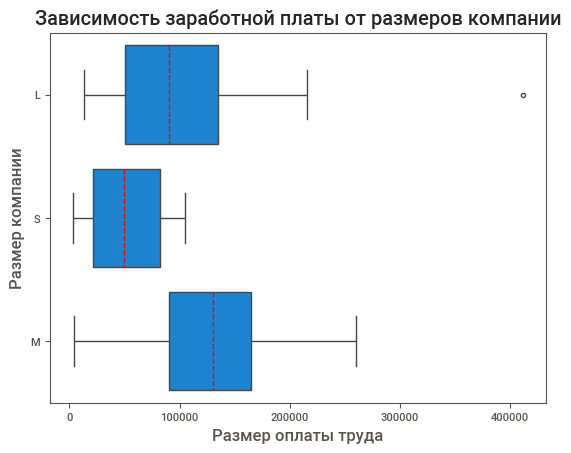

In [190]:
# строим график
ax = sns.boxplot(filtred_ds, x='salary_in_usd', y='company_size', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер оплаты труда', ylabel='Размер компании')
plt.title('Зависимость заработной платы от размеров компании')
plt.show()

In [191]:
# вычисляем основные статистические показатели
data_agg = filtred_ds.groupby('company_size')['salary_in_usd'].describe().round(2)
print('Зависимость заработной платы от размера компании')
data_agg

Зависимость заработной платы от размера компании


,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
L,45.0,103313.36,71815.18,13400.0,50000.0,90734.0,135000.0,412000.0
M,77.0,126380.75,56389.53,4000.0,90000.0,130000.0,165000.0,260000.0
S,21.0,51925.76,33216.29,2859.0,21669.0,49268.0,82500.0,105000.0


Среднее значение оплаты труда значительно отличается в зависимости от компании, при этом можно сделать предварительный вывод о том, что чем больше компания, тем выше средняя зарплата соимкателей. 

Чтобы определить, являются ли эти различия статистически значимыми, необходимы статистические тесты.

### - Взаимосвязь между наличием должностей Data Scientist и Data Engineer и размером компании?

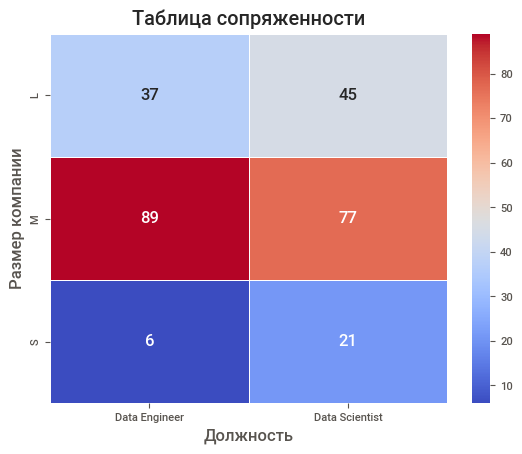

In [208]:
# строим кросс таблицу 
cross_table = pd.crosstab(filtred_ds_de['company_size'], filtred_ds_de['job_title'])
# формируем тепловой график
ax = sns.heatmap(cross_table, annot=True, linewidth=.5, fmt='.0f', cmap="coolwarm")
ax.set(xlabel='Должность', ylabel='Размер компании')
plt.title('Таблица сопряженности')
plt.show()

Взаимосвязь между наличием должностей Data Scientist и Data Engineer и размером компании визуально присутствует. 

Чтобы определить, являются ли эта взаимосвязь статистически значимой, необходимы статистические тесты.

### 2.1. Статистический анализ данных

In [192]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))
      

### - Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): размер зарплат у специалистов Data Scientist в 2020 г. ($μ_1$) меньше или равен размеру зарплат у специалистов Data Scientist в 2021 г. ($μ_2$) и размер зарплат у специалистов Data Scientist в 2021 г. ($μ_2$) меньше или равен размеру зарплат у специалистов Data Scientist в 2022 г. ($μ_3$)

$$ H_0 : μ_1 <= μ_2; μ_2 <= μ_3$$

*Альтернативная гипотеза* ($H_0$): размер зарплат у специалистов Data Scientist в 2020 г. ($μ_1$) больше размера зарплат у специалистов Data Scientist в 2021 г. ($μ_2$) и размер зарплат у специалистов Data Scientist в 2021 г. ($μ_2$) больше размера зарплат у специалистов Data Scientist в 2022 г. ($μ_3$)

$$ H_1 : μ_1 > μ_2; μ_2 > μ_3$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально. Напомним гипотезы теста Шапиро-Уилка:

*Нулевая гипотеза* ($H_0$): распределение данные является нормальным.

*Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [197]:
# значения года выплаты
ds_salary_20 = filtred_ds.loc[filtred_ds['work_year']==2020, 'salary_in_usd']
ds_salary_21 = filtred_ds.loc[filtred_ds['work_year']==2021, 'salary_in_usd']
ds_salary_22 = filtred_ds.loc[filtred_ds['work_year']==2022, 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('2020')
result = stats.shapiro(ds_salary_20)
decision_normality(result[1])

print('2021')
result = stats.shapiro(ds_salary_21)
decision_normality(result[1])

print('2022')
result = stats.shapiro(ds_salary_22)
decision_normality(result[1])

2020
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
2021
p-value = 0.125
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
2022
p-value = 0.327
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным


В 2020 году распределение не было нормальным.

**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «salary_in_usd»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет (у нас нет информации о том какие соискатели участвуют в датасете, возможно это были разные группы соискателей).
* Признак распределён по нормальному закону? — Нет.

Чтобы проверить нашу гипотезу, можно использовать КРИТЕРИЙ КРАСКЕЛА — УОЛЛИСА.

**Проведём тест:**

In [194]:
# проводим тест
_, p = stats.kruskal(ds_salary_20, ds_salary_21, ds_salary_22)

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


**Вывод:**

Наблюдается ежегодный рост зарплат у специалистов Data Scientist.


### - Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?

**Сформулируем нулевую и альтернативные гипотезы:**

*Нулевая гипотеза* ($H_0$): размер зарплаты Data Scientist ($μ_1$) и Data Engineer ($μ_2$) в 2022 году статистически не отличаются ($μ_2$).

$$ H_0 : μ_1 = μ_2$$

*Альтернативная гипотеза* ($H_1$): размер зарплаты Data Scientist ($μ_1$) и Data Engineer ($μ_2$) в 2022 году статистически отличаются ($μ_2$).

$$ H_1 : μ_1 ≠ μ_2$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально. Напомним гипотезы теста Шапиро-Уилка:

*Нулевая гипотеза* ($H_0$): распределение данные является нормальным.

*Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [198]:
filtred_ds_de
# значения зарплат
salary_ds = filtred_ds_de.loc[filtred_ds_de['job_title']=='Data Scientist', 'salary_in_usd']
salary_de = filtred_ds_de.loc[filtred_ds_de['job_title']=='Data Engineer', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Data Scientist')
result = stats.shapiro(salary_ds)
decision_normality(result[1])

print('Data Engineer:')
result = stats.shapiro(salary_de)
decision_normality(result[1])

Data Scientist
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Data Engineer:
p-value = 0.010
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


По обоим профессиям распределение отлично от нормального.

**Выберем подходящий статистический тест:**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «salary_in_usd»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Чтобы проверить нашу гипотезу, можно использовать U-критерий Манна — Уитни для сравнения распределений на основе рангов.

**Проведём тест:**

In [199]:
# проводим тест
_, p = stats.mannwhitneyu(salary_ds, salary_de, alternative='greater')
decision_hypothesis(p)

p-value = 0.767
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


Визуальные отличия зарплаты Data Scientist и Data Engineer не являются статистически существенными, можно сделать вывод что они совпадают.

### - Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: размер зарплаты специалистов Data Scientist в компаниях различных размеров не отличается: S — менее 50 сотрудников ($μ_1$), M — от 50 до 250 сотрудников ($μ_2$), L — более 250 сотрудников ($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3$$

*Альтернативная гипотеза*: размер зарплаты специалистов Data Scientist в компаниях различных размеров отличается: S — менее 50 сотрудников ($μ_1$), M — от 50 до 250 сотрудников ($μ_2$), L — более 250 сотрудников ($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [202]:
# значения года выплаты
ds_salary_s = filtred_ds.loc[filtred_ds['company_size']=='S', 'salary_in_usd']
ds_salary_m = filtred_ds.loc[filtred_ds['company_size']=='M', 'salary_in_usd']
ds_salary_l = filtred_ds.loc[filtred_ds['company_size']=='L', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('S — менее 50 сотрудников (небольшая компания)')
result = stats.shapiro(ds_salary_s)
decision_normality(result[1])
print()
print('M — от 50 до 250 сотрудников (средняя компания)')
result = stats.shapiro(ds_salary_m)
decision_normality(result[1])
print()
print('L — более 250 сотрудников (крупная компания)')
result = stats.shapiro(ds_salary_l)
decision_normality(result[1])

S — менее 50 сотрудников (небольшая компания)
p-value = 0.189
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным

M — от 50 до 250 сотрудников (средняя компания)
p-value = 0.639
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным

L — более 250 сотрудников (крупная компания)
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


В крупных компаниях распредиление признака не нормальное.

**Выберем подходящий статистический тест:**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «salary_in_usd»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест:**

In [203]:
# проводим тест
_, p = stats.kruskal(ds_salary_s, ds_salary_m, ds_salary_l)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод:**

Различия в зарплатах специалистов Data Scientist в компаниях различных размеров существенно отличается.

### - Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: связь между наличием должностей Data Scientist и Data Engineer и размером компании отсутствует (признаки независимы).

*Альтернативная гипотеза*: связь между наличием должностей Data Scientist и Data Engineer и размером компании присутствует (признаки зависимы).

**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Пол»? — Категориальный.
* Сколько сравниваемых групп? — Две.
* Проверяется независимость групп? — Да.

Для проверки нашей гипотезы можно использовать критерий ${\chi}^2$ (хи-квадрат).

**Проведём тест**

In [204]:
# составляем таблицу сопряжённости
cross_table = pd.crosstab(filtred_ds_de['company_size'], filtred_ds_de['job_title'])

cross_table

job_title,Data Engineer,Data Scientist
company_size,,
L,37,45
M,89,77
S,6,21


In [205]:
# проводим тест
_, p, _, _ = stats.chi2_contingency(cross_table)
decision_hypothesis(p)

p-value = 0.008
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Существует статистически значимая взаимосвязь между наличием должностей Data Scientist и Data Engineer и размером компании, например в маленьких компаниях чаще работают Data Scientist и реже Data Engineer.

## 3. Дополнительное исследование

По данным полученным из отчета по основным статистическим характеристикам признакам датасета, средняя оплата труда во всем датасете составляет 112 тысяч долларов.

### - Привышает ли оплата труда Data Scientist за весь рассматриваемый период среднюю оплату труда по всем соискателям представленным в изначальной таблице?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): оплата труда Data Scientist за весь рассматриваемый период ($μ_1$) не привышает среднюю оплату труда 112 тысяч $.

$$ H_0 : μ_1 <= 112000$$

*Альтернативная гипотеза* ($H_1$): оплата труда Data Scientist за весь рассматриваемый период ($μ_1$) больше средней оплаты труда 112 тысяч $.

$$ H_1 : μ_1 > 112000$$

**Проверка на нормальность**

In [210]:
# значения года выплаты
#ds_salary_s = filtred_ds.loc[filtred_ds['company_size']=='S', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Распредиление зарплаты Data Scientist')
result = stats.shapiro(filtred_ds['salary_in_usd'])
decision_normality(result[1])

Распредиление зарплаты Data Scientist
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


Распределение отлично от нормального. Прповедем тест Критерий знаков (для одной группы):

In [211]:
from statsmodels.stats.descriptivestats import sign_test

# проводим тест
_, p = sign_test(filtred_ds['salary_in_usd'], 112000)

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.403
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


**Вывод:**

Средняя оплата труда Data Scientist за весь рассматриваемый период ($μ_1$) не привышает общую среднюю оплату труда 112 тысяч $

### - Как соотносятся зарплаты специалистов Data Scientist в зависимости от Типа трудоустройства?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: размер зарплаты специалистов Data Scientist в зависимости от опыта работы не отличается: S — менее 50 сотрудников ($μ_1$), M — от 50 до 250 сотрудников ($μ_2$), L — более 250 сотрудников ($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3$$

*Альтернативная гипотеза*: размер зарплаты специалистов Data Scientist в компаниях различных размеров отличается: S — менее 50 сотрудников ($μ_1$), M — от 50 до 250 сотрудников ($μ_2$), L — более 250 сотрудников ($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально. Напомним гипотезы теста Шапиро-Уилка:

*Нулевая гипотеза* ($H_0$): распределение данные является нормальным.

*Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [ ]:
# значения года выплаты
ds_salary_s = filtred_ds.loc[filtred_ds['company_size']=='S', 'salary_in_usd']
ds_salary_m = filtred_ds.loc[filtred_ds['company_size']=='M', 'salary_in_usd']
ds_salary_l = filtred_ds.loc[filtred_ds['company_size']=='L', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('S — менее 50 сотрудников (небольшая компания)')
result = stats.shapiro(ds_salary_s)
decision_normality(result[1])
print()
print('M — от 50 до 250 сотрудников (средняя компания)')
result = stats.shapiro(ds_salary_m)
decision_normality(result[1])
print()
print('L — более 250 сотрудников (крупная компания)')
result = stats.shapiro(ds_salary_l)
decision_normality(result[1])

**Выберем подходящий статистический тест:**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «salary_in_usd»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест:**

**Вывод:**

Различия в зарплатах специалистов Data Scientist в компаниях различных размеров существенно отличается.